# Northern Lights open-data foundation and NeqSim model basis

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/northern_lights/01_northern_lights_open_data_foundation.ipynb)
[![NeqSim](https://img.shields.io/badge/NeqSim-current_master-0072B2)](https://github.com/equinor/neqsim)

This standalone tutorial establishes a governed data and model basis for the Northern Lights CCS chain. It audits small licensed 31/5-7 Eos well snapshots, reconciles interpreted Cook–Johansen intervals with public well facts, and uses a source-built NeqSim runtime for CO2 and formation-water property anchors, an injection-column hydrostatic screen, and capacity translation.

The calculation is deliberately an **engineering foundation**, not a storage certification or operating model. OPM Flow remains the recommended simulator for dynamic reservoir pressure, plume, trapping, and well-control calculations; NeqSim owns thermodynamics, well/pipeline/facility models, process dynamics, and operational envelopes.


## Learning outcomes and claim boundary

After completing the notebook, you should be able to:

1. distinguish licensed source snapshots, external interpretations, curated public facts, calculated derivatives, and scenario assumptions;
2. configure a reproducible open-snapshot run or explicitly select an installed Databricks Marketplace volume;
3. quality-control trajectory, formation, core-strength, and well-test evidence before it enters a model;
4. select NeqSim EOS-CG for dense CO2 property screening and CPA for a salt-free water reference;
5. translate public annual capacities into mass and dense-volume rates without treating the public figure as a design flow;
6. issue discipline-specific handoffs to NeqSim and OPM Flow with explicit missing-data gates.

**Not a design basis.** The wellhead pressure, seabed temperature, thermal profile, pure-CO2 composition, and salt-free water case are labelled scenario assumptions. Real design requires the measured CO2 acceptance composition, formation-water analysis, pressure data, completion geometry, injectivity interpretation, pipeline profile, thermal boundary, operating controls, geomechanics, and permit constraints.

**Data licence.** Copyright Equinor ASA and the Northern Lights collaboration partners Total E&P Norge AS and A/S Norske Shell. The bundled files are used under the [Northern Lights terms and conditions](https://github.com/GeoArkadeep/supporting-data-for-EOS-Northern-Lights/blob/main/LICENSE). The licensed material may not be sold; attribution and a link to the terms are required. The formation and UCS files come from a [supporting-data repository](https://github.com/GeoArkadeep/supporting-data-for-EOS-Northern-Lights) whose author calls them a subjective interpretation and disclaims factual accuracy and endorsement.


## 1. Reproducible source-built NeqSim runtime

The setup cell selects the exact NeqSim Java commit that was `master` when this notebook was published. It builds that source in Colab, or verifies a prebuilt JAR from the same checkout in CI. The Python package is only the JPype bridge; the printed Java class location, commit, and JAR digest identify the numerical runtime.


In [1]:
import hashlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import platform
import subprocess
import sys
from urllib.parse import unquote, urlparse

NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_COMMIT = "647b4b84e10cf354e5688a22a72c359f801d0cc3"
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

required_packages = {
    "jpype": "JPype1>=1.5",
    "matplotlib": "matplotlib>=3.8",
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.2",
    "neqsim": "neqsim==3.17.0",
}
missing = [
    requirement
    for module, requirement in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing],
        check=True,
        timeout=900,
    )

source_root_override = os.environ.get("NEQSIM_SOURCE_ROOT")
source_jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
dependency_jar_override = os.environ.get("NEQSIM_DEPENDENCY_JAR")
SOURCE_ROOT = Path(
    source_root_override or "/content/neqsim-northern-lights-source"
).resolve()

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--filter=blob:none",
            "--no-checkout",
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
        timeout=600,
    )
if source_root_override:
    resolved_commit = subprocess.check_output(
        ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()
else:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--depth=1",
            "origin",
            NEQSIM_SOURCE_COMMIT,
        ],
        check=True,
        timeout=600,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--detach",
            NEQSIM_SOURCE_COMMIT,
        ],
        check=True,
    )
    resolved_commit = subprocess.check_output(
        ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()

assert resolved_commit == NEQSIM_SOURCE_COMMIT
if source_jar_override:
    SOURCE_JAR = Path(source_jar_override).resolve()
    build_mode = "prebuilt JAR from the exact source checkout"
else:
    os.environ.setdefault(
        "MAVEN_USER_HOME", "/tmp/neqsim-northern-lights-m2"
    )
    subprocess.run(
        [
            str(SOURCE_ROOT / "mvnw"),
            "-q",
            "-Dmaven.repo.local=/tmp/neqsim-northern-lights-m2/repository",
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=SOURCE_ROOT,
        check=True,
        timeout=1800,
    )
    candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not candidates:
        raise FileNotFoundError("NeqSim source build produced no runtime JAR.")
    SOURCE_JAR = max(candidates, key=lambda path: path.stat().st_size)
    build_mode = "Maven package from exact current-master commit"

assert SOURCE_JAR.is_file()
SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the source JAR was selected. Restart and run all."
    )
jpype.addClassPath(str(SOURCE_JAR))
if dependency_jar_override:
    jpype.addClassPath(str(Path(dependency_jar_override).resolve()))
from neqsim.neqsimpython import init_jvm

init_jvm()
MAIN_ONLY_CLASS = jpype.JClass(
    "neqsim.process.dynamics.DynamicCapabilityReport"
)
location_url = str(
    MAIN_ONLY_CLASS.class_.getProtectionDomain().getCodeSource().getLocation()
)
loaded_path = Path(unquote(urlparse(location_url).path)).resolve()
assert loaded_path == SOURCE_JAR.resolve()

java_version = subprocess.check_output(
    ["java", "-version"], stderr=subprocess.STDOUT, text=True
).splitlines()[0]
print("NeqSim source ref:", NEQSIM_SOURCE_REF)
print("NeqSim source commit:", resolved_commit)
print("Build mode:", build_mode)
print("Source JAR SHA-256:", SOURCE_JAR_SHA256)
print("Loaded main-only class from:", loaded_path)
print("NeqSim Python bridge:", importlib.metadata.version("neqsim"))
print("Python:", platform.python_version())
print("Java:", java_version)


NeqSim source ref: master
NeqSim source commit: 647b4b84e10cf354e5688a22a72c359f801d0cc3
Build mode: prebuilt JAR from the exact source checkout
Source JAR SHA-256: 5c6f26b0529aa04905c518ba6320a49ca237de055d708d55b49e82a78289055b
Loaded main-only class from: /workspace/scratch/d7e477da1e31/neqsim-source/target/neqsim-4.0.0-SNAPSHOT-source-classes.jar
NeqSim Python bridge: 3.17.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## 2. Series position and data modes

This is notebook 1 of a planned seven-notebook Northern Lights sequence. It creates the evidence contract consumed by later stream-acceptance, terminal/pipeline/injection, Eos well-test, thermal-geomechanics, OPM Flow storage, and integrated-operations studies.

The default `open-snapshot` mode is credential-free and reproducible. To inventory an installed or exported Marketplace volume, set `NORTHERN_LIGHTS_DATA_MODE=marketplace` and `NORTHERN_LIGHTS_VOLUME_ROOT` before execution. An invalid Marketplace path raises an error; the code never silently substitutes teaching data.


In [2]:
import math
import shutil

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#666666",
}

relative_series = Path("notebooks/fielddevelopment/northern_lights")
series_candidates = [Path.cwd(), Path.cwd() / relative_series]
SERIES_DIR = next(
    (
        candidate.resolve()
        for candidate in series_candidates
        if (candidate / "northern_lights_common.py").is_file()
    ),
    None,
)
if SERIES_DIR is None:
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=600,
        )
    SERIES_DIR = repository_dir / relative_series
sys.path.insert(0, str(SERIES_DIR))

import northern_lights_common as nlc

source = nlc.resolve_source()
display(nlc.source_table(source))

if source.mode == "marketplace-local-volume":
    marketplace_inventory = nlc.inventory_local_volume(Path(source.root))
    display(
        marketplace_inventory.groupby("domain", as_index=False).agg(
            files=("relative_path", "size"), bytes=("bytes", "sum")
        )
    )
else:
    marketplace_inventory = None


,item,value
0,mode,open-snapshot
1,root,/workspace/scratch/d7e477da1e31/neqsim-colab/n...
2,authoritative_boundary,https://marketplace.databricks.com/details/ea2...
3,measured_or_interpreted_data_loaded,True
4,claim_boundary,Small licensed and interpreted Eos snapshots o...


## 3. Hash-checked open snapshots and provenance classes

The full Northern Lights package is roughly 850 files and more than 83 GB according to the [Equinor disclosure](https://www.equinor.com/news/archive/20201019-sharing-data-northern-lights). Its [Databricks Marketplace listing](https://marketplace.databricks.com/details/ea296770-0ee0-4b74-a202-a2c0873add7c/Equinor-ASA_Northern-Lights) describes well logs, biostratigraphy, formation pressure, fluid data, well tests, core data, drilling, and completion information.

Only four small files are bundled here. Their digests protect the tutorial from an unnoticed data change; the provenance class prevents an interpreted formation table from becoming a false raw-data claim.


In [3]:
snapshot_manifest = nlc.verify_snapshot_hashes()
display(
    snapshot_manifest.assign(
        sha256=lambda frame: frame["sha256"].str.slice(0, 16) + "…"
    )
)

provenance_ledger = pd.DataFrame(
    [
        ["Deviation survey", "LICENSED_OPEN_SNAPSHOT", "bundled CSV", "trajectory QA"],
        ["Image markers", "LICENSED_OPEN_SNAPSHOT", "bundled CSV", "data-location context"],
        ["Formation intervals", "EXTERNAL_INTERPRETATION", "bundled CSV", "interval reconciliation only"],
        ["UCS versus depth", "EXTERNAL_INTERPRETATION", "bundled CSV", "rock-strength context only"],
        ["Eos well facts", "CURATED_PUBLIC_FACT", "SODIR snapshot", "well/test context"],
        ["Phase 1 and Phase 2 rates", "CURATED_PUBLIC_FACT", "Northern Lights pages", "capacity translation"],
        ["CO2 and water properties", "DERIVED_NEQSIM", "exact source runtime", "screening property anchors"],
        ["Wellhead pressure and thermal path", "SCENARIO_ASSUMPTION", "declared below", "hydrostatic sensitivity"],
    ],
    columns=["item", "provenance_class", "source", "permitted_use_here"],
)
display(provenance_ledger)


,file,bytes,sha256,hash_matches,origin_commit,evidence_class
0,31_5-7_Image.csv,33,1a3cf3d79d7644c1…,True,4d24c01cb893a3d80d1c4e25a3dde0ebbf178839,licensed open snapshot
1,Deviation.csv,3727,2a5758a50acb3f80…,True,4d24c01cb893a3d80d1c4e25a3dde0ebbf178839,licensed open snapshot
2,NorthernLights-31_5-7.csv,2087,db5611c7e0b2351c…,True,4d24c01cb893a3d80d1c4e25a3dde0ebbf178839,external interpretation
3,UCSdata.csv,487,780f451f1a2808c5…,True,4d24c01cb893a3d80d1c4e25a3dde0ebbf178839,external interpretation


,item,provenance_class,source,permitted_use_here
0,Deviation survey,LICENSED_OPEN_SNAPSHOT,bundled CSV,trajectory QA
1,Image markers,LICENSED_OPEN_SNAPSHOT,bundled CSV,data-location context
2,Formation intervals,EXTERNAL_INTERPRETATION,bundled CSV,interval reconciliation only
3,UCS versus depth,EXTERNAL_INTERPRETATION,bundled CSV,rock-strength context only
4,Eos well facts,CURATED_PUBLIC_FACT,SODIR snapshot,well/test context
5,Phase 1 and Phase 2 rates,CURATED_PUBLIC_FACT,Northern Lights pages,capacity translation
6,CO2 and water properties,DERIVED_NEQSIM,exact source runtime,screening property anchors
7,Wellhead pressure and thermal path,SCENARIO_ASSUMPTION,declared below,hydrostatic sensitivity


## 4. Normalize and quality-control the Eos evidence

The deviation header in the source snapshot contains unquoted commas inside coordinate labels. The shared loader therefore assigns an explicit nine-column schema rather than trusting automatic header parsing. Formation thickness is derived as

$$h_i = z_{i,\mathrm{bottom}} - z_{i,\mathrm{top}}$$

and is not a new measurement. Gaps, zero-thickness markers, and missing intervals are retained as evidence issues rather than interpolated away.


In [4]:
tables = nlc.load_snapshot_tables()
deviation = tables["deviation"]
formations = tables["formations"]
ucs = tables["ucs"]
image_markers = tables["image_markers"]

key_families = formations[formations["family"].ne("other")].copy()
family_summary = (
    key_families.groupby("family", as_index=False)
    .agg(
        top_m=("structural_top_m", "min"),
        bottom_m=("structural_bottom_m", "max"),
        interpreted_thickness_m=("thickness_m", "sum"),
        subintervals=("formation", "size"),
    )
    .sort_values("top_m")
)

ordered = formations.sort_values(["structural_top_m", "Number"]).copy()
ordered["gap_from_previous_m"] = (
    ordered["structural_top_m"] - ordered["structural_bottom_m"].shift()
)
material_gaps = ordered[ordered["gap_from_previous_m"].gt(0.5)][
    ["formation", "structural_top_m", "gap_from_previous_m"]
]

trajectory_qc = pd.DataFrame(
    {
        "metric": [
            "survey stations",
            "terminal MD [m]",
            "terminal TVD [m]",
            "maximum inclination [deg]",
            "terminal horizontal displacement [m]",
            "maximum dogleg [deg/30 m]",
            "MD monotonic",
            "TVD monotonic",
        ],
        "value": [
            len(deviation),
            deviation["MD_m"].iloc[-1],
            deviation["TVD_m"].iloc[-1],
            deviation["inclination_deg"].max(),
            math.hypot(
                deviation["x_offset_m"].iloc[-1],
                deviation["y_offset_m"].iloc[-1],
            ),
            deviation["dogleg_deg_per_30m"].max(),
            deviation["MD_m"].is_monotonic_increasing,
            deviation["TVD_m"].is_monotonic_increasing,
        ],
    }
)
display(trajectory_qc)
display(family_summary)
display(material_gaps)


,metric,value
0,survey stations,53
1,terminal MD [m],2915.0
2,terminal TVD [m],2914.89
3,maximum inclination [deg],1.66
4,terminal horizontal displacement [m],9.889506
5,maximum dogleg [deg/30 m],1.28
6,MD monotonic,True
7,TVD monotonic,True


,family,top_m,bottom_m,interpreted_thickness_m,subintervals
1,Drake seal,2510,2585,75,2
0,Cook reservoir,2638,2695,57,3
2,Johansen reservoir,2702,2818,116,4


,formation,structural_top_m,gap_from_previous_m
24,Cook3,2638,53.0


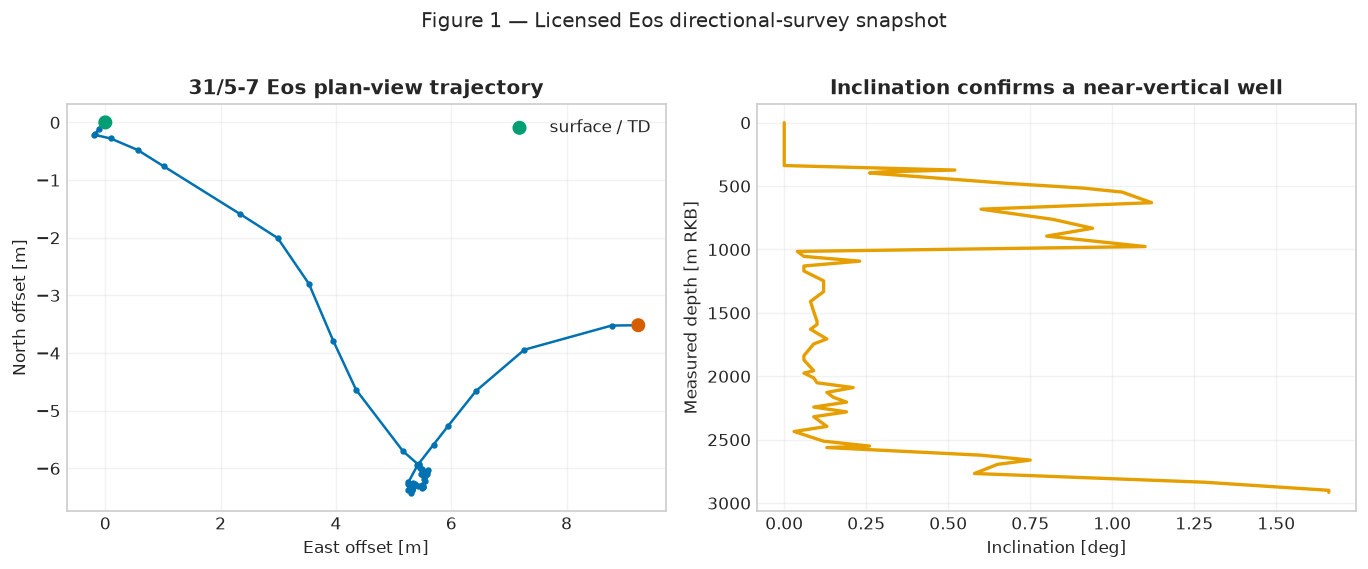

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].plot(
    deviation["x_offset_m"],
    deviation["y_offset_m"],
    color=COLORS["blue"],
    marker="o",
    markersize=2.8,
)
axes[0].scatter(
    deviation["x_offset_m"].iloc[[0, -1]],
    deviation["y_offset_m"].iloc[[0, -1]],
    c=[COLORS["green"], COLORS["red"]],
    s=55,
    zorder=4,
    label="surface / TD",
)
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].set_xlabel("East offset [m]")
axes[0].set_ylabel("North offset [m]")
axes[0].set_title("31/5-7 Eos plan-view trajectory")
axes[0].legend(loc="best")

axes[1].plot(
    deviation["inclination_deg"],
    deviation["MD_m"],
    color=COLORS["orange"],
    linewidth=2.0,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Inclination [deg]")
axes[1].set_ylabel("Measured depth [m RKB]")
axes[1].set_title("Inclination confirms a near-vertical well")
fig.suptitle("Figure 1 — Licensed Eos directional-survey snapshot", y=1.02)
fig.tight_layout()
plt.show()


### Figure 1 discussion

**Observation.** The 53-station snapshot ends at 2915.0 m MD and 2914.89 m TVD. Maximum inclination is 1.66°, maximum dogleg is 1.28°/30 m, and terminal horizontal displacement is about 9.9 m.

**Physical mechanism.** A near-vertical trajectory makes MD and TVD almost identical; small plan-view departures accumulate from low-angle changes rather than a designed lateral section.

**Engineering implication.** TVD-based pressure and stratigraphic screening is adequate at this foundation stage, but a completion or wellbore model must retain the full directional survey, reference datum, casing/tubing geometry, and temperature profile.

**Recommendation.** Use the Marketplace directional-survey files as the authoritative wellpath input in the injectivity notebook and verify datum and units before connecting them to a NeqSim well model.


,family,samples,minimum_ucs_mpa,median_ucs_mpa,maximum_ucs_mpa
0,Cook reservoir,17,31,35.0,45
1,Johansen reservoir,28,18,33.0,65


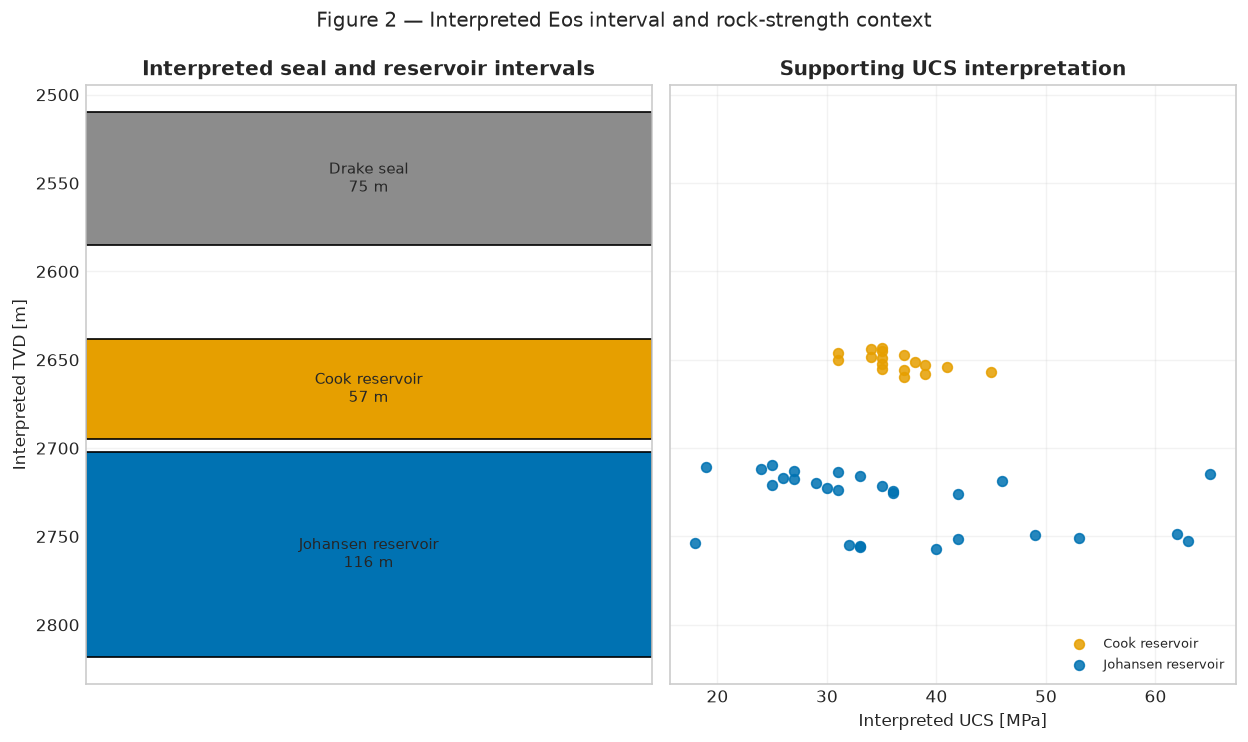

In [6]:
def family_at_depth(depth_m):
    matches = key_families[
        key_families["structural_top_m"].le(depth_m)
        & key_families["structural_bottom_m"].gt(depth_m)
    ]
    return matches["family"].iloc[0] if len(matches) else "unassigned"

ucs = ucs.assign(family=ucs["depth_m"].map(family_at_depth))
ucs_summary = (
    ucs.groupby("family", as_index=False)
    .agg(
        samples=("ucs_mpa", "size"),
        minimum_ucs_mpa=("ucs_mpa", "min"),
        median_ucs_mpa=("ucs_mpa", "median"),
        maximum_ucs_mpa=("ucs_mpa", "max"),
    )
    .sort_values("family")
)
display(ucs_summary)

family_colors = {
    "Drake seal": "#8C8C8C",
    "Cook reservoir": COLORS["orange"],
    "Johansen reservoir": COLORS["blue"],
    "unassigned": COLORS["red"],
}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 6.2), sharey=True)
for _, row in family_summary.iterrows():
    axes[0].barh(
        y=row["top_m"],
        width=1.0,
        height=row["bottom_m"] - row["top_m"],
        align="edge",
        color=family_colors[row["family"]],
        edgecolor="black",
        label=row["family"],
    )
    axes[0].text(
        0.5,
        0.5 * (row["top_m"] + row["bottom_m"]),
        f"{row['family']}\n{row['interpreted_thickness_m']:.0f} m",
        ha="center",
        va="center",
        fontsize=9,
    )
axes[0].set_xlim(0, 1)
axes[0].set_xticks([])
axes[0].set_ylabel("Interpreted TVD [m]")
axes[0].set_title("Interpreted seal and reservoir intervals")

for family, subset in ucs.groupby("family"):
    axes[1].scatter(
        subset["ucs_mpa"],
        subset["depth_m"],
        s=34,
        alpha=0.85,
        label=family,
        color=family_colors.get(family, COLORS["purple"]),
    )
axes[1].set_xlabel("Interpreted UCS [MPa]")
axes[1].set_title("Supporting UCS interpretation")
axes[1].legend(loc="lower right", fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Figure 2 — Interpreted Eos interval and rock-strength context", y=0.99)
fig.tight_layout()
plt.show()


### Figure 2 discussion

**Observation.** The supporting interpretation contains 75 m of Drake, 57 m of Cook, and 116 m of Johansen. Cook plus Johansen is 173 m, exactly reconciling with the [SODIR statement](https://www.sodir.no/en/whats-new/news/general-news/2020/cook-and-johansen-formations-are-good-candidates-for-co2-storage--315-7/) that the two formations comprise 173 m of high-quality sandstone. The 45 interpreted UCS points range from 18 to 65 MPa. A 53 m interval is absent between interpreted Drake and Cook entries.

**Physical mechanism.** The strength scatter reflects lithology, cementation, sample location, and interpretation method; it is not a continuous log. The 173 m match is a reconciliation check, not proof that the sub-interval boundaries are authoritative.

**Engineering implication.** The table can define tutorial zones and sampling locations, but it cannot establish fracture pressure, safe injection pressure, caprock integrity, or a geomechanical model.

**Recommendation.** Replace the interpreted intervals with the Marketplace formation-top record and use the openly published rock-mechanics and thermo-mechanical laboratory work in the dedicated thermal-geomechanics notebook.


## 5. Public well and project facts

The following values are a curated, dated snapshot from the [SODIR 31/5-7 Eos fact page](https://factpages.sodir.no/en/storage/PageView/Wellbores/All/8951), the [SODIR result summary](https://www.sodir.no/en/whats-new/news/general-news/2020/cook-and-johansen-formations-are-good-candidates-for-co2-storage--315-7/), and Northern Lights project pages. They are public context, not a substitute for the original files or permit documents.

The Eos well was drilled in 2019–2020 in 307 m water depth to 2915 m MD/2914.9 m TVD. SODIR reports a 2697.5–2805 m DST interval, roughly 1000 m3/day water and 600 Sm3/day gas during the main test, an observation radius of 2200–3200 m, and about 110 °C near 2770 m. The public Eos target included at least 0.8 Mt/year injection. Northern Lights describes Phase 1 as 1.5 Mt/year and Phase 2 as at least 5 Mt/year.


In [7]:
well_facts = pd.DataFrame(
    [
        ["water depth", 307.0, "m", "SODIR well fact"],
        ["TD MD", 2915.0, "m RKB", "SODIR well fact"],
        ["TD TVD", 2914.9, "m RKB", "SODIR well fact"],
        ["bottom-hole temperature", 115.0, "degC", "SODIR well fact"],
        ["DST top", 2697.5, "m", "SODIR well result"],
        ["DST bottom", 2805.0, "m", "SODIR well result"],
        ["DST water rate", 1000.0, "m3/day", "approximate public value"],
        ["DST gas rate", 600.0, "Sm3/day", "approximate public value"],
        ["pressure observation radius low", 2200.0, "m", "public interpretation"],
        ["pressure observation radius high", 3200.0, "m", "public interpretation"],
        ["temperature near 2770 m", 110.0, "degC", "public test context"],
    ],
    columns=["quantity", "value", "unit", "evidence"],
)
capacity_facts = pd.DataFrame(
    [
        ["Eos minimum target", 0.8, "SODIR well result"],
        ["Northern Lights Phase 1", 1.5, "Northern Lights public capacity"],
        ["Northern Lights Phase 2 minimum", 5.0, "Northern Lights expansion statement"],
    ],
    columns=["case", "capacity_Mt_per_year", "evidence"],
)
display(well_facts)
display(capacity_facts)


,quantity,value,unit,evidence
0,water depth,307.0,m,SODIR well fact
1,TD MD,2915.0,m RKB,SODIR well fact
2,TD TVD,2914.9,m RKB,SODIR well fact
3,bottom-hole temperature,115.0,degC,SODIR well fact
4,DST top,2697.5,m,SODIR well result
5,DST bottom,2805.0,m,SODIR well result
6,DST water rate,1000.0,m3/day,approximate public value
7,DST gas rate,600.0,Sm3/day,approximate public value
8,pressure observation radius low,2200.0,m,public interpretation
9,pressure observation radius high,3200.0,m,public interpretation


,case,capacity_Mt_per_year,evidence
0,Eos minimum target,0.8,SODIR well result
1,Northern Lights Phase 1,1.5,Northern Lights public capacity
2,Northern Lights Phase 2 minimum,5.0,Northern Lights expansion statement


## 6. Evidence coverage versus model needs

The Marketplace package contains much more than the bundled subset. This matrix makes the consequence explicit: a public fact can orient a model, but only a selected and quality-controlled source asset can support parameterization. `Available in Marketplace` means the listing/source package describes that evidence class; it does not mean this execution loaded or accepted the file.


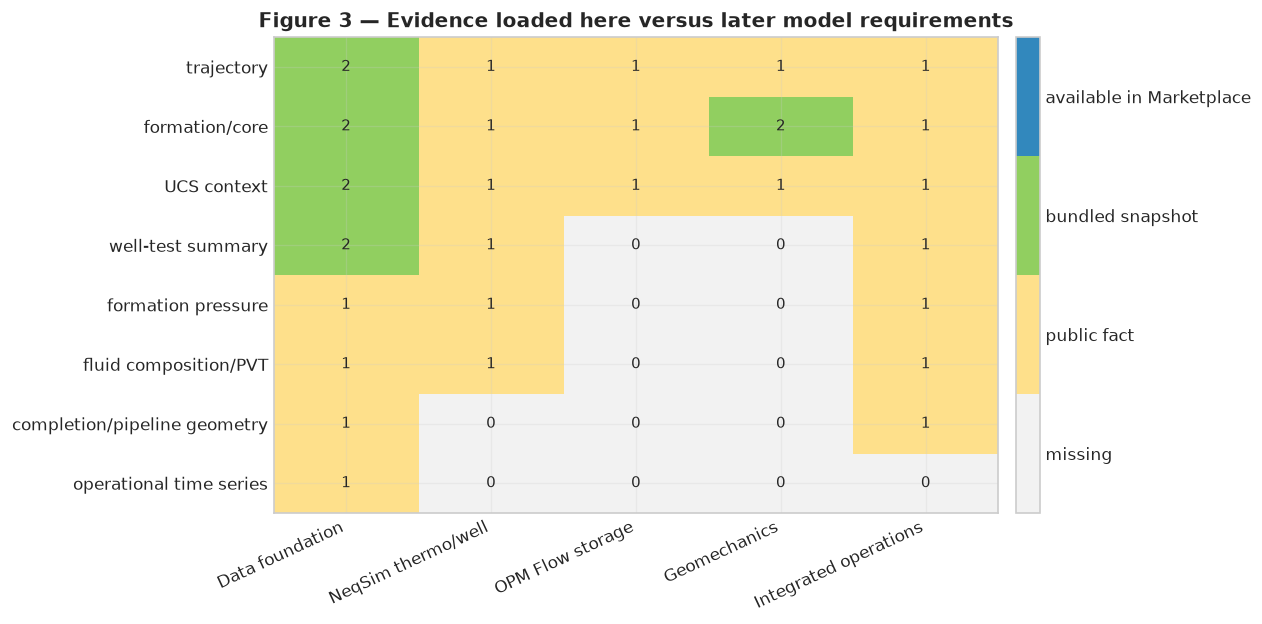

In [8]:
coverage_labels = [
    "missing",
    "public fact",
    "bundled snapshot",
    "available in Marketplace",
]
coverage = pd.DataFrame(
    {
        "Data foundation": [2, 2, 2, 2, 1, 1, 1, 1],
        "NeqSim thermo/well": [1, 1, 1, 1, 1, 1, 0, 0],
        "OPM Flow storage": [1, 1, 1, 0, 0, 0, 0, 0],
        "Geomechanics": [1, 2, 1, 0, 0, 0, 0, 0],
        "Integrated operations": [1, 1, 1, 1, 1, 1, 1, 0],
    },
    index=[
        "trajectory",
        "formation/core",
        "UCS context",
        "well-test summary",
        "formation pressure",
        "fluid composition/PVT",
        "completion/pipeline geometry",
        "operational time series",
    ],
)

fig, ax = plt.subplots(figsize=(10.5, 5.3))
image = ax.imshow(
    coverage.to_numpy(),
    aspect="auto",
    cmap=ListedColormap(["#F2F2F2", "#FEE08B", "#91CF60", "#3288BD"]),
    vmin=-0.5,
    vmax=3.5,
)
ax.set_xticks(range(len(coverage.columns)), coverage.columns, rotation=25, ha="right")
ax.set_yticks(range(len(coverage.index)), coverage.index)
for row in range(coverage.shape[0]):
    for column in range(coverage.shape[1]):
        value = int(coverage.iat[row, column])
        ax.text(column, row, str(value), ha="center", va="center", fontsize=9)
colorbar = fig.colorbar(image, ax=ax, ticks=range(4), pad=0.02)
colorbar.ax.set_yticklabels(coverage_labels)
ax.set_title("Figure 3 — Evidence loaded here versus later model requirements")
fig.tight_layout()
plt.show()


### Figure 3 discussion

**Observation.** This notebook has strong reproducible coverage for trajectory and interval teaching, but formation pressure, measured fluid composition/PVT, completion geometry, detailed pipeline geometry, and operational time series are not loaded.

**Physical mechanism.** Thermodynamics and hydraulics depend on composition, pressure, temperature, geometry, and boundary conditions; reservoir and geomechanical forecasts additionally depend on spatial rock properties and constitutive behavior. A file inventory alone does not supply those parameters.

**Engineering implication.** The property and hydrostatic calculations below must remain scenario screens. They cannot be promoted to an injectivity, containment, or operating-envelope conclusion.

**Recommendation.** Before notebook 4 or 6, install the Marketplace share, select the exact pressure/fluid/test/core/trajectory assets, record their hashes and units, and run domain acceptance checks.


## 7. NeqSim CO2 and water property anchors

Dense CO2 transport and injection are very sensitive to pressure, temperature, and impurities. This foundation uses pure CO2 with NeqSim EOS-CG and a salt-free water reference with SRK-CPA. Neither fluid is claimed to match the delivered CO2 specification or Eos formation water.

For a single equilibrium phase, density connects annual mass capacity to local volume rate:

$$\dot V = \frac{\dot m}{\rho(P,T,\mathbf{x})}$$

Impurity and salinity studies are deliberately deferred until measured compositions are selected from the open-data package.


In [9]:
SystemEOSCGEos = jneqsim.thermo.system.SystemEOSCGEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)


def pure_co2_state(temperature_c, pressure_bara):
    system = SystemEOSCGEos(float(temperature_c) + 273.15, float(pressure_bara))
    system.addComponent("CO2", 1.0)
    operations = ThermodynamicOperations(system)
    operations.TPflash()
    system.initProperties()
    phase = system.getPhase(0)
    return {
        "temperature_c": float(temperature_c),
        "pressure_bara": float(pressure_bara),
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_cp": float(system.getViscosity("cP")),
        "enthalpy_kj_kg": float(system.getEnthalpy("kJ/kg")),
        "cp_kj_kgk": float(phase.getCp("kJ/kgK")),
        "sound_speed_m_s": float(phase.getSoundSpeed()),
        "phase_count": int(system.getNumberOfPhases()),
        "phase": str(phase.getPhaseTypeName()),
    }


def salt_free_water_state(temperature_c, pressure_bara):
    system = SystemSrkCPAstatoil(
        float(temperature_c) + 273.15, float(pressure_bara)
    )
    system.addComponent("water", 1.0)
    system.setMixingRule(10)
    operations = ThermodynamicOperations(system)
    operations.TPflash()
    system.initProperties()
    phase = system.getPhase(0)
    return {
        "temperature_c": float(temperature_c),
        "pressure_bara": float(pressure_bara),
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_cp": float(system.getViscosity("cP")),
        "phase": str(phase.getPhaseTypeName()),
    }


pressure_grid_bara = np.array([80.0, 110.0, 140.0, 180.0, 220.0, 260.0])
temperature_grid_c = np.array([15.0, 50.0, 80.0, 110.0])
property_rows = [
    pure_co2_state(temperature_c, pressure_bara)
    for temperature_c in temperature_grid_c
    for pressure_bara in pressure_grid_bara
]
co2_properties = pd.DataFrame(property_rows)
water_reference = pd.DataFrame(
    [salt_free_water_state(110.0, pressure) for pressure in (100.0, 180.0, 260.0)]
)
display(co2_properties.round(4))
display(water_reference.round(4))


,temperature_c,pressure_bara,density_kg_m3,viscosity_cp,enthalpy_kj_kg,cp_kj_kgk,sound_speed_m_s,phase_count,phase
0,15.0,80.0,868.4580,0.0737,-273.9266,2.6743,480.7128,1,gas
1,15.0,110.0,899.5652,0.0823,-277.9084,2.3849,538.8014,1,gas
2,15.0,140.0,923.2270,0.0895,-280.4337,2.2235,584.1773,1,gas
3,15.0,180.0,948.4427,0.0980,-282.5519,2.0889,633.8438,1,gas
4,15.0,220.0,969.1843,0.1056,-283.7856,1.9997,675.7906,1,gas
5,15.0,260.0,986.9582,0.1126,-284.4332,1.9353,712.5439,1,gas
6,50.0,80.0,219.1998,0.0224,-70.4370,2.5080,224.8693,1,gas
7,50.0,110.0,502.6385,0.0408,-152.3356,6.0818,238.5809,1,gas
8,50.0,140.0,672.3923,0.0530,-187.7745,3.3735,336.8619,1,gas
9,50.0,180.0,757.0913,0.0636,-202.5443,2.5493,426.2725,1,gas


,temperature_c,pressure_bara,density_kg_m3,viscosity_cp,phase
0,110.0,100.0,968.3823,0.2604,aqueous
1,110.0,180.0,972.6516,0.2632,aqueous
2,110.0,260.0,976.7468,0.2660,aqueous


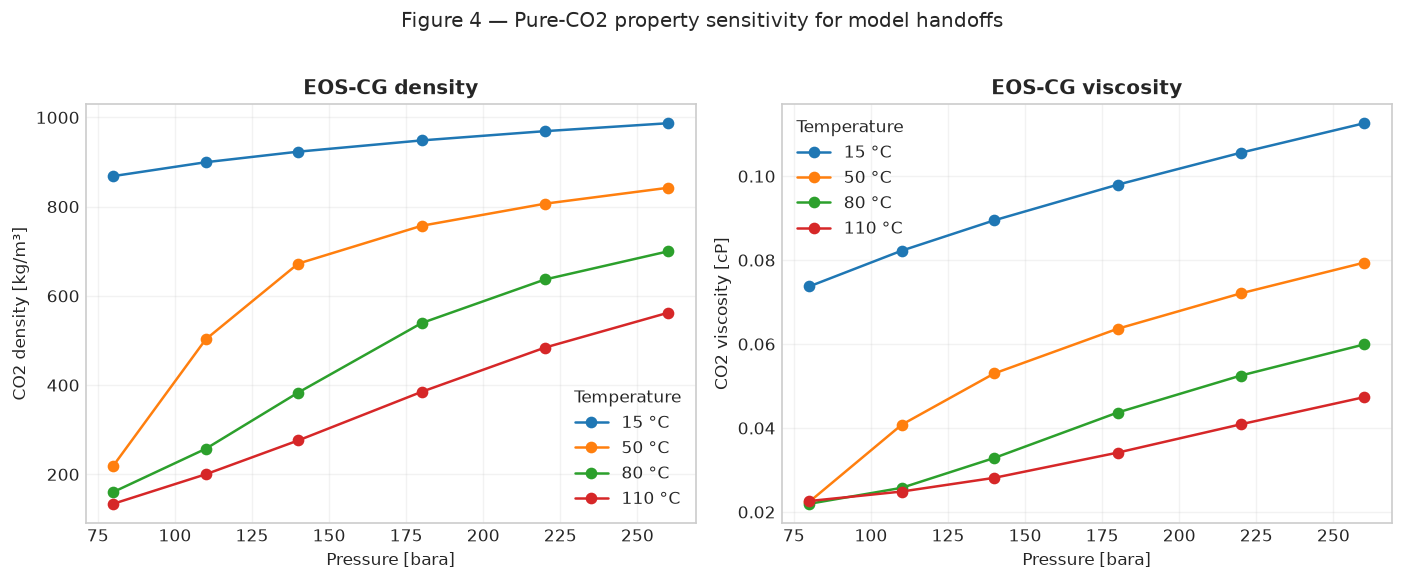

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.7))
for temperature_c, subset in co2_properties.groupby("temperature_c"):
    label = f"{temperature_c:.0f} °C"
    axes[0].plot(
        subset["pressure_bara"],
        subset["density_kg_m3"],
        marker="o",
        label=label,
    )
    axes[1].plot(
        subset["pressure_bara"],
        subset["viscosity_cp"],
        marker="o",
        label=label,
    )
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("CO2 density [kg/m³]")
axes[0].set_title("EOS-CG density")
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("CO2 viscosity [cP]")
axes[1].set_title("EOS-CG viscosity")
for axis in axes:
    axis.legend(title="Temperature")
fig.suptitle("Figure 4 — Pure-CO2 property sensitivity for model handoffs", y=1.02)
fig.tight_layout()
plt.show()


### Figure 4 discussion

**Observation.** EOS-CG predicts a strong pressure and temperature dependence across 80–260 bara and 15–110 °C. At 15 °C density rises from 868 to 987 kg/m³, while at 110 °C it rises from 134 to 562 kg/m³ over the same pressure range. All 24 tabulated cases are finite, positive, and single phase in this selected grid.

**Physical mechanism.** CO2 compressibility is large near the critical region, while increasing temperature reduces density at a fixed pressure. Viscosity changes with the same molecular packing and pressure-density response.

**Engineering implication.** One standard-volume or constant-density conversion cannot represent terminal storage, cold dense transport, warm wellbore flow, and reservoir entry. Pressure drop, pump duty, linepack, heat transfer, and wellbore hydrostatics need local properties.

**Recommendation.** In notebook 2, replace pure CO2 with the measured/contractual acceptance composition, compare EOS-CG against qualified reference data over the complete envelope, and quantify impurity uncertainty before sizing or control conclusions.


## 8. Injection-column hydrostatic screen

The screen integrates a vertical, frictionless pure-CO2 column from the seabed to 2770 m TVD. It assumes 100 bara and 8 °C at the seabed, a linear warming to 110 °C, and equilibrium EOS-CG density at every node:

$$P_{i+1} = P_i + \rho\!\left(\bar P_i,\bar T_i\right) g\,\Delta z_i$$

This is an implicit density-pressure calculation only. It excludes tubing/casing geometry, friction, acceleration, heat-transfer transients, impurities, completion pressure loss, reservoir pressure, and well controls.


,TVD_m,temperature_c,pressure_bara,density_kg_m3
0,307.0,8.0,100.000,932.143
10,799.6,28.4,143.043,849.511
20,1292.2,48.8,182.091,767.990
30,1784.8,69.2,217.389,695.544
40,2277.4,89.6,249.522,637.332
50,2770.0,110.0,279.190,593.051


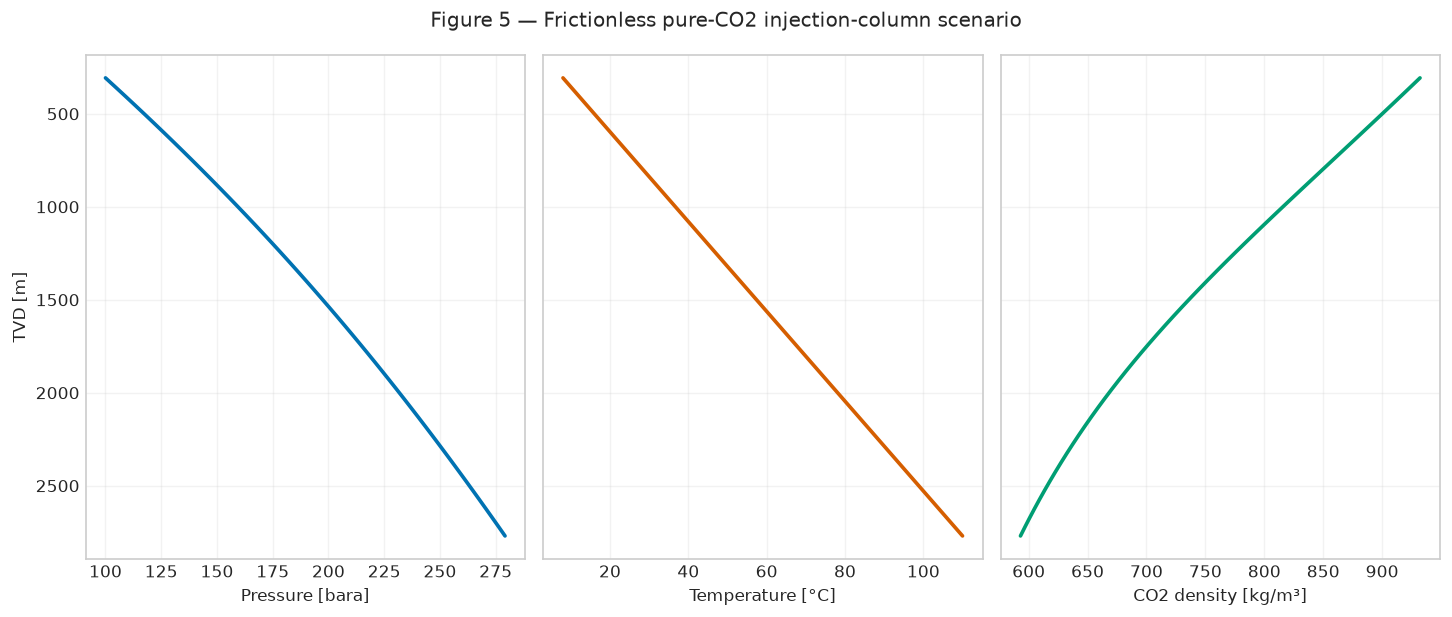

In [11]:
SEABED_TVD_M = 307.0
SCREEN_BOTTOM_TVD_M = 2770.0
WELLHEAD_PRESSURE_BARA = 100.0
SEABED_TEMPERATURE_C = 8.0
BOTTOM_TEMPERATURE_C = 110.0
GRAVITY_M_S2 = 9.80665


def hydrostatic_co2_profile(number_of_nodes=51):
    tvd = np.linspace(SEABED_TVD_M, SCREEN_BOTTOM_TVD_M, number_of_nodes)
    temperature = np.linspace(
        SEABED_TEMPERATURE_C, BOTTOM_TEMPERATURE_C, number_of_nodes
    )
    pressure = np.empty(number_of_nodes)
    density = np.empty(number_of_nodes)
    pressure[0] = WELLHEAD_PRESSURE_BARA
    density[0] = pure_co2_state(temperature[0], pressure[0])["density_kg_m3"]
    for index in range(1, number_of_nodes):
        dz = tvd[index] - tvd[index - 1]
        trial_pressure = pressure[index - 1]
        for _ in range(20):
            average_pressure = 0.5 * (pressure[index - 1] + trial_pressure)
            average_temperature = 0.5 * (
                temperature[index - 1] + temperature[index]
            )
            average_density = pure_co2_state(
                average_temperature, average_pressure
            )["density_kg_m3"]
            updated_pressure = (
                pressure[index - 1]
                + average_density * GRAVITY_M_S2 * dz / 1.0e5
            )
            if abs(updated_pressure - trial_pressure) < 1.0e-7:
                break
            trial_pressure = 0.5 * (trial_pressure + updated_pressure)
        pressure[index] = updated_pressure
        density[index] = pure_co2_state(
            temperature[index], pressure[index]
        )["density_kg_m3"]
    return pd.DataFrame(
        {
            "TVD_m": tvd,
            "temperature_c": temperature,
            "pressure_bara": pressure,
            "density_kg_m3": density,
        }
    )


hydrostatic_profile = hydrostatic_co2_profile()
display(hydrostatic_profile.iloc[[0, 10, 20, 30, 40, 50]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(12.2, 5.2), sharey=True)
for axis, column, label, color in [
    (axes[0], "pressure_bara", "Pressure [bara]", COLORS["blue"]),
    (axes[1], "temperature_c", "Temperature [°C]", COLORS["red"]),
    (axes[2], "density_kg_m3", "CO2 density [kg/m³]", COLORS["green"]),
]:
    axis.plot(hydrostatic_profile[column], hydrostatic_profile["TVD_m"], color=color, linewidth=2.2)
    axis.set_xlabel(label)
axes[0].set_ylabel("TVD [m]")
axes[0].invert_yaxis()
fig.suptitle("Figure 5 — Frictionless pure-CO2 injection-column scenario", y=0.98)
fig.tight_layout()
plt.show()


### Figure 5 discussion

**Observation.** Pressure rises monotonically from the declared 100 bara seabed boundary to 279.2 bara at 2770 m while temperature rises from 8 to the public 110 °C test context. Density falls from 932 to 593 kg/m³ because warming outweighs the compression effect along this declared path.

**Physical mechanism.** Gravity adds pressure in proportion to local density; EOS-CG recomputes that density from the evolving pressure-temperature state. The result is a coupled hydrostatic profile rather than a constant-gradient line.

**Engineering implication.** A pressure margin evaluated only at the terminal or wellhead can misstate the bottom-hole condition. Friction during injection, cooldown after shutdown, restart, and impurity-sensitive phase behavior can shift the path further.

**Recommendation.** Use this profile only as the initialization check for notebook 3/4. Replace every scenario boundary with accepted project data, add real completion geometry and heat transfer, and couple the bottom-hole boundary to an OPM Flow injectivity case.


## 9. Translate public capacities without turning them into design rates

Annual capacity is converted using 365.25 days/year. Dense volume is evaluated at the final hydrostatic state, solely to expose the thermodynamic conversion. Availability, ship unloading batches, terminal inventory, pump turndown, well allocation, downtime, and design margin are excluded.


,case,capacity_Mt_per_year,evidence,average_mass_rate_kg_s,dense_volume_m3_h_at_screen_bottom,relative_to_phase_1
0,Eos minimum target,0.8,SODIR well result,25.350,153.885,0.533
1,Northern Lights Phase 1,1.5,Northern Lights public capacity,47.532,288.534,1.000
2,Northern Lights Phase 2 minimum,5.0,Northern Lights expansion statement,158.440,961.781,3.333


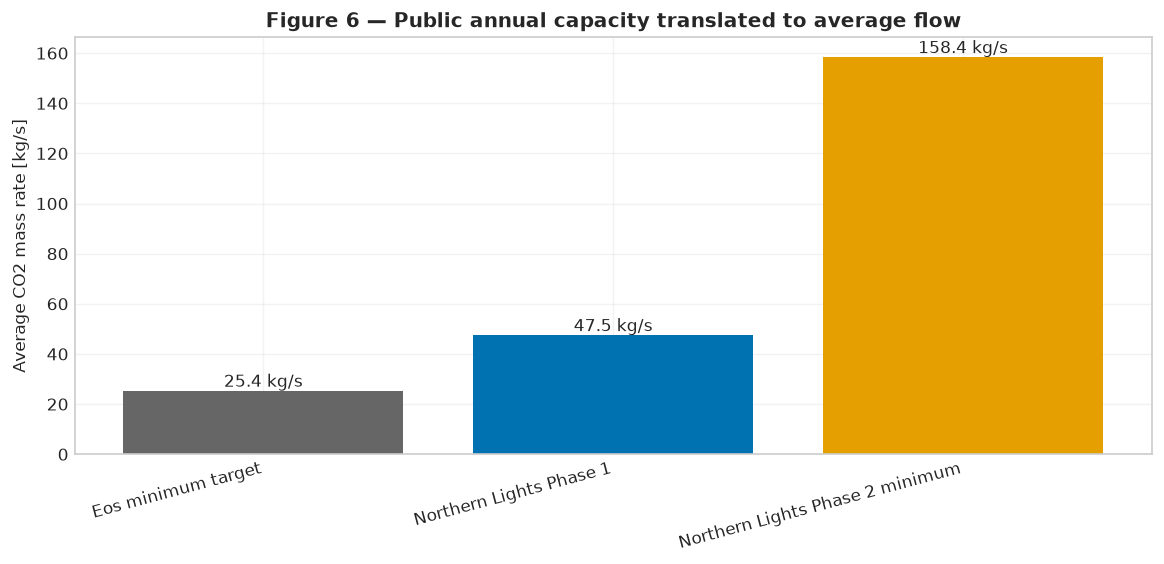

In [12]:
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
bottom_state = hydrostatic_profile.iloc[-1]
bottom_density = bottom_state["density_kg_m3"]

capacity = capacity_facts.copy()
capacity["average_mass_rate_kg_s"] = (
    capacity["capacity_Mt_per_year"] * 1.0e9 / SECONDS_PER_YEAR
)
capacity["dense_volume_m3_h_at_screen_bottom"] = (
    capacity["average_mass_rate_kg_s"] / bottom_density * 3600.0
)
capacity["relative_to_phase_1"] = (
    capacity["capacity_Mt_per_year"]
    / capacity.loc[
        capacity["case"].eq("Northern Lights Phase 1"),
        "capacity_Mt_per_year",
    ].iloc[0]
)
display(capacity.round(3))

fig, axis = plt.subplots(figsize=(9.8, 4.8))
positions = np.arange(len(capacity))
bars = axis.bar(
    positions,
    capacity["average_mass_rate_kg_s"],
    color=[COLORS["grey"], COLORS["blue"], COLORS["orange"]],
)
axis.set_xticks(positions, capacity["case"], rotation=15, ha="right")
axis.set_ylabel("Average CO2 mass rate [kg/s]")
axis.set_title("Figure 6 — Public annual capacity translated to average flow")
for bar, value in zip(bars, capacity["average_mass_rate_kg_s"]):
    axis.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f"{value:.1f} kg/s",
        ha="center",
        va="bottom",
    )
fig.tight_layout()
plt.show()


### Figure 6 discussion

**Observation.** The 0.8, 1.5, and 5.0 Mt/year public figures translate to 25.4, 47.5, and 158.4 kg/s as continuous annual averages. At the 593 kg/m³ screened bottom state, those are 154, 289, and 962 m³/h. Phase 2 is 3.33 times Phase 1.

**Physical mechanism.** Mass conversion is linear, while local volume depends on the EOS-CG density at the chosen pressure-temperature state. Batch receipt, availability, and operational peaks do not disappear merely because annual totals are averaged.

**Engineering implication.** The average rate is a mass-balance anchor, not a pump, pipeline, heater, or well design point. Phase 2 can require additional wells and equipment even if reservoir capacity is adequate.

**Recommendation.** Notebook 3 should build hourly and campaign cases from ship/terminal constraints, facility availability, well allocation, turndown, and design margins, then use NeqSim equipment and pipeline models at each operating state.


## 10. Discipline handoffs and acceptance gates

The owner of each calculation matters. NeqSim supplies fluid properties and connected well/pipeline/facility behavior. OPM Flow supplies spatial reservoir pressure, saturation, plume, and well-control response. Geomechanics and monitoring require their specialist tools and accepted data. The table prevents a convenient notebook calculation from quietly replacing a qualified model.


In [13]:
handoff = pd.DataFrame(
    [
        ["open-data foundation", "this notebook", "hashes, schemas, units, provenance, accepted rows", "all required source classes explicit"],
        ["CO2 fluid basis", "NeqSim", "accepted composition, P-T range, water/impurity limits", "EOS/reference validation passed"],
        ["terminal and pipeline", "NeqSim ProcessSystem and pipeline models", "geometry, roughness, heat transfer, pumps, controls", "mass/energy closure and envelope margins"],
        ["injection well", "NeqSim well model", "trajectory, completion, thermal boundary, BHP contract", "hydraulic/thermal benchmark passed"],
        ["storage reservoir", "OPM Flow", "grid, rock, PVT, relperm/capillary, wells, schedule", "real Flow run, material balance, refinement"],
        ["geomechanics", "qualified geomechanical workflow", "stress, strength, thermal path, pressure history", "fracture/containment criteria reviewed"],
        ["integrated operations", "coupled NeqSim–OPM workflow", "versioned boundaries and scenario identity", "normal/turndown/shutdown/restart accepted"],
    ],
    columns=["discipline product", "model owner", "minimum input contract", "acceptance gate"],
)
display(handoff)


,discipline product,model owner,minimum input contract,acceptance gate
0,open-data foundation,this notebook,"hashes, schemas, units, provenance, accepted rows",all required source classes explicit
1,CO2 fluid basis,NeqSim,"accepted composition, P-T range, water/impurit...",EOS/reference validation passed
2,terminal and pipeline,NeqSim ProcessSystem and pipeline models,"geometry, roughness, heat transfer, pumps, con...",mass/energy closure and envelope margins
3,injection well,NeqSim well model,"trajectory, completion, thermal boundary, BHP ...",hydraulic/thermal benchmark passed
4,storage reservoir,OPM Flow,"grid, rock, PVT, relperm/capillary, wells, sch...","real Flow run, material balance, refinement"
5,geomechanics,qualified geomechanical workflow,"stress, strength, thermal path, pressure history",fracture/containment criteria reviewed
6,integrated operations,coupled NeqSim–OPM workflow,versioned boundaries and scenario identity,normal/turndown/shutdown/restart accepted


## 11. Engineering checks, conclusions, and next notebook

Checks below verify reproducibility, geometry consistency, interval reconciliation, finite NeqSim properties, physical hydrostatic trends, capacity algebra, and model ownership. Passing means this educational foundation is internally coherent—not that Northern Lights injection design or storage assurance is validated.


In [14]:
drake_thickness = family_summary.loc[
    family_summary["family"].eq("Drake seal"), "interpreted_thickness_m"
].iloc[0]
reservoir_thickness = family_summary.loc[
    family_summary["family"].isin(["Cook reservoir", "Johansen reservoir"]),
    "interpreted_thickness_m",
].sum()

checks = {
    "all four snapshot hashes match": bool(snapshot_manifest["hash_matches"].all()),
    "trajectory MD is monotonic": bool(deviation["MD_m"].is_monotonic_increasing),
    "trajectory TVD is monotonic": bool(deviation["TVD_m"].is_monotonic_increasing),
    "trajectory remains below 2 degrees inclination": bool(deviation["inclination_deg"].max() < 2.0),
    "terminal TVD reconciles within 0.1 m": bool(abs(deviation["TVD_m"].iloc[-1] - 2914.9) < 0.1),
    "Drake interpretation sums to 75 m": bool(abs(drake_thickness - 75.0) < 1.0e-9),
    "Cook plus Johansen interpretation sums to 173 m": bool(abs(reservoir_thickness - 173.0) < 1.0e-9),
    "UCS interpretation is finite and positive": bool(np.isfinite(ucs["ucs_mpa"]).all() and ucs["ucs_mpa"].gt(0.0).all()),
    "EOS-CG property grid is finite and positive": bool(np.isfinite(co2_properties.select_dtypes("number")).all().all() and co2_properties["density_kg_m3"].gt(0.0).all()),
    "EOS-CG selected grid is single phase": bool(co2_properties["phase_count"].eq(1).all()),
    "CPA water reference is finite and liquid-like": bool(np.isfinite(water_reference["density_kg_m3"]).all() and water_reference["density_kg_m3"].gt(700.0).all()),
    "hydrostatic pressure rises monotonically": bool(hydrostatic_profile["pressure_bara"].is_monotonic_increasing),
    "hydrostatic bottom pressure exceeds wellhead pressure": bool(hydrostatic_profile["pressure_bara"].iloc[-1] > WELLHEAD_PRESSURE_BARA),
    "Phase 2 to Phase 1 capacity ratio is 10/3": bool(abs(capacity["relative_to_phase_1"].iloc[-1] - 10.0 / 3.0) < 1.0e-12),
    "handoff assigns both NeqSim and OPM Flow": bool(handoff["model owner"].str.contains("NeqSim").any() and handoff["model owner"].str.contains("OPM Flow").any()),
}
check_table = pd.DataFrame(
    {"engineering check": list(checks), "status": ["PASS" if value else "FAIL" for value in checks.values()]}
)
display(check_table)
failed = [name for name, passed in checks.items() if not passed]
assert not failed, f"Engineering checks failed: {failed}"
print(f"All {len(checks)} engineering checks passed.")

final_summary = pd.DataFrame(
    [
        ["runtime", resolved_commit[:12], "exact source-built NeqSim master snapshot"],
        ["data", "4 hash-checked files", "licensed snapshot plus explicit interpretations"],
        ["geometry", f"{deviation['TVD_m'].iloc[-1]:.2f} m TVD", "near-vertical Eos trajectory"],
        ["intervals", f"{reservoir_thickness:.0f} m Cook+Johansen", "reconciles to SODIR public result"],
        ["hydrostatic scenario", f"{hydrostatic_profile['pressure_bara'].iloc[-1]:.1f} bara at 2770 m", "pure CO2, frictionless, declared thermal path"],
        ["capacity anchor", f"{capacity['average_mass_rate_kg_s'].iloc[-1]:.1f} kg/s", "5 Mt/year continuous average, not design flow"],
        ["next notebook", "CO2 stream thermodynamic basis", "measured/contractual composition and model validation"],
    ],
    columns=["result", "value", "interpretation boundary"],
)
display(final_summary)


All 15 engineering checks passed.


,engineering check,status
0,all four snapshot hashes match,PASS
1,trajectory MD is monotonic,PASS
2,trajectory TVD is monotonic,PASS
3,trajectory remains below 2 degrees inclination,PASS
4,terminal TVD reconciles within 0.1 m,PASS
5,Drake interpretation sums to 75 m,PASS
6,Cook plus Johansen interpretation sums to 173 m,PASS
7,UCS interpretation is finite and positive,PASS
8,EOS-CG property grid is finite and positive,PASS
9,EOS-CG selected grid is single phase,PASS


,result,value,interpretation boundary
0,runtime,647b4b84e10c,exact source-built NeqSim master snapshot
1,data,4 hash-checked files,licensed snapshot plus explicit interpretations
2,geometry,2914.89 m TVD,near-vertical Eos trajectory
3,intervals,173 m Cook+Johansen,reconciles to SODIR public result
4,hydrostatic scenario,279.2 bara at 2770 m,"pure CO2, frictionless, declared thermal path"
5,capacity anchor,158.4 kg/s,"5 Mt/year continuous average, not design flow"
6,next notebook,CO2 stream thermodynamic basis,measured/contractual composition and model val...


## Conclusions

- The bundled open snapshots are sufficient to teach traceable ingestion, trajectory QA, interval reconciliation, and data-gap management without redistributing the full Marketplace package.
- The near-vertical Eos trajectory and the 173 m Cook–Johansen reconciliation are strong internal checks. The 53 m formation-table gap and third-party interpretation status are equally important findings.
- Source-built NeqSim EOS-CG provides the local CO2 property basis needed to translate annual capacity and screen a pressure-temperature path. The salt-free CPA water result is only a reference until the measured water analysis is selected.
- The hydrostatic case exposes why injection-bottom conditions cannot be inferred from a terminal value alone, but it excludes the physics required for a well design or injectivity forecast.
- The correct next step is the Northern Lights-specific CO2 stream thermodynamic basis. Dynamic reservoir work waits for selected open pressure/rock/fluid data and a verified OPM Flow execution path.

### Primary sources

- [Equinor Northern Lights Databricks Marketplace listing](https://marketplace.databricks.com/details/ea296770-0ee0-4b74-a202-a2c0873add7c/Equinor-ASA_Northern-Lights)
- [Equinor announcement of the Northern Lights data release](https://www.equinor.com/news/archive/20201019-sharing-data-northern-lights)
- [SODIR 31/5-7 Eos well fact page](https://factpages.sodir.no/en/storage/PageView/Wellbores/All/8951)
- [SODIR Eos result summary](https://www.sodir.no/en/whats-new/news/general-news/2020/cook-and-johansen-formations-are-good-candidates-for-co2-storage--315-7/)
- [Northern Lights reports](https://norlights.com/reports-2/)
- [Northern Lights Phase 2 expansion statement](https://norlights.com/news/northern-lights-is-expanding-capacity-through-commercial-agreement/)
- [CO2DataShare Eos rock-mechanics dataset](https://co2datashare.org/dataset/rock-mechanics-data-for-31-5-7-eos-well-core)
- [CO2DataShare Eos thermo-mechanical dataset](https://co2datashare.org/dataset/rock-mechanics-data-for-31-5-7-eos-well-thermo-mechanical-response)
